# 08 XGBoost
Deep Dive möglichst noch ohne Hyperparameter Optimierung. Ziel: Entscheidungsfindung für Modelle

## Import

In [1]:
import time

import numpy as np
import pandas as pd

from sklearn.datasets import fetch_openml
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.compose import ColumnTransformer, make_column_transformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, TargetEncoder
from sklearn.metrics import roc_auc_score
from sklearn.base import clone

from xgboost import XGBClassifier

import matplotlib as mpl
import matplotlib.pyplot as plt

In [2]:
mpl.style.use("seaborn-v0_8-colorblind")
RANDOM_STATE = 42

## Dataframe

In [3]:
df_raw = fetch_openml(data_id=42742, as_frame=True).frame

In [4]:
feat_cols = [col for col in df_raw.columns if col not in ("target",)]
cat_cols = [col for col in feat_cols if col.endswith("_cat")]
bin_cols = [col for col in feat_cols if col.endswith("_bin")]
num_cols = [col for col in feat_cols if col not in cat_cols and col not in bin_cols]

for col in cat_cols:
    df_raw[col] = df_raw[col].astype("category")

for col in bin_cols:
    if df_raw[col].isna().sum() == 0:
        df_raw[col] = df_raw[col].astype(int).astype("bool")
    else:
        df_raw[col] = df_raw[col].astype("Int8")

for col in num_cols:
    df_raw[col] = df_raw[col].astype("float32")

df_raw["target"] = df_raw["target"].astype(int).astype("bool")

idx_train = np.load("../../../data/processed/train_idx.npy")
idx_val = np.load("../../../data/processed/val_idx.npy")
idx_test = np.load("../../../data/processed/test_idx.npy")

df_train = df_raw.iloc[idx_train]
df_val = df_raw.iloc[idx_val]
df_test = df_raw.iloc[idx_test]

x_train, y_train = df_train[feat_cols], df_train["target"]
x_val, y_val = df_val[feat_cols], df_val["target"]
x_test, y_test = df_test[feat_cols], df_test["target"]

pd.Series(
    {
        "train": [len(df_train), len(x_train), len(y_train)],
        "val": [len(df_val), len(x_val), len(y_val)],
        "test": [len(df_test), len(x_test), len(y_test)]
    }
)

train    [476168, 476168, 476168]
val         [59522, 59522, 59522]
test        [59522, 59522, 59522]
dtype: object

## Hilfsvariablen

In [21]:
calc_cols = [c for c in feat_cols if c.startswith("ps_calc_")]

mv_cols = ["ps_car_03_cat", "ps_car_05_cat", "ps_reg_03", "ps_car_14"]

num_cols_no_calc = [c for c in num_cols if c not in calc_cols]
bin_cols_no_calc = [c for c in bin_cols if c not in calc_cols]
feat_cols_no_calc = [c for c in feat_cols if c not in calc_cols]

high_kard_cols = ["ps_car_11_cat"]
low_kard_cols = [c for c in cat_cols if c not in high_kard_cols]

In [6]:
train_times = {}
results = []

In [9]:
def eval_modell(mod_idx, model, x_train, y_train, x_val, y_val, train_time, best_iter=None):
    """AUC auf Train und Val"""
    auc_train = roc_auc_score(y_train, model.predict_proba(x_train)[:, 1])
    auc_val = roc_auc_score(y_val, model.predict_proba(x_val)[:, 1])
    return {
        "model_idx": mod_idx,
        "auc_train": auc_train,
        "auc_val": auc_val,
        "gini": 2 * auc_val - 1,
        "delta_auc": auc_train - auc_val,
        "best_iter": best_iter,
        "trainingszeit": train_time
    }

## L_xgb_01

In [8]:
xgb_01 = make_pipeline(
    make_column_transformer(
        ("passthrough", num_cols),
        (OneHotEncoder(handle_unknown="ignore", sparse_output=False), low_kard_cols),
        (TargetEncoder(cv=5, shuffle=True, random_state=RANDOM_STATE), high_kard_cols),
        ("passthrough", bin_cols)
    ),
    XGBClassifier(
        booster="gbtree",
        random_state=RANDOM_STATE,
        eval_metric="auc",
        tree_method="hist"
    )
)

In [10]:
name = "L_xgb_01"

start = time.time()
xgb_01.fit(x_train, y_train)
train_times[name] = time.time() - start

c:\Users\Linus Lauschke\anaconda3\envs\ADA\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


In [11]:
results.append(eval_modell(name, xgb_01, x_train, y_train, x_val, y_val, train_times[name]))
pd.DataFrame(results).set_index("model_idx")

,auc_train,auc_val,gini,delta_auc,best_iter,trainingszeit
model_idx,,,,,,
L_xgb_01,0.787872,0.61735,0.2347,0.170522,None,9.158222


## L_xgb_02

In [12]:
xgb_02 = XGBClassifier(
    booster="gbtree",
    random_state=RANDOM_STATE,
    eval_metric="auc",
    tree_method="hist",
    n_estimators=1000,
    learning_rate=0.05,
    early_stopping_rounds=50
)

In [14]:
name = "L_xgb_02"

start = time.time()
xgb_02.fit(
    x_train, y_train,
    eval_set=[(x_train, y_train), (x_val, y_val)],
    verbose=250
)
train_times[name] = time.time() - start

[0]	validation_0-auc:0.62712	validation_1-auc:0.59354
[141]	validation_0-auc:0.74808	validation_1-auc:0.62234


In [15]:
results.append(
    eval_modell(name, xgb_02, x_train, y_train, x_val, y_val,
                train_times[name], best_iter=xgb_02.best_iteration)
)
pd.DataFrame(results).set_index("model_idx")

,auc_train,auc_val,gini,delta_auc,best_iter,trainingszeit
model_idx,,,,,,
L_xgb_01,0.787872,0.61735,0.23470,0.170522,NaN,9.158222
L_xgb_02,0.720702,0.62426,0.24852,0.096442,91.0,32.358830


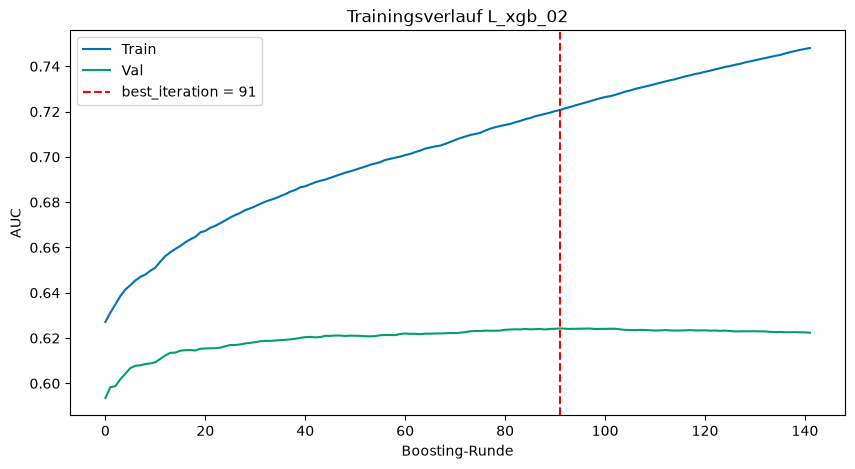

In [19]:
hist = xgb_02.evals_result()

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(hist["validation_0"]["auc"], label="Train")
ax.plot(hist["validation_1"]["auc"], label="Val")
ax.axvline(xgb_02.best_iteration,color="red", linestyle="--",
           label=f"best_iteration = {xgb_02.best_iteration}")
ax.set_xlabel("Boosting-Runde")
ax.set_ylabel("AUC")
ax.set_title("Trainingsverlauf L_xgb_02")
ax.legend()

In [16]:
xgb_02MK2 = XGBClassifier(
    booster="gbtree",
    random_state=RANDOM_STATE,
    eval_metric="auc",
    tree_method="hist",
    n_estimators=5000,
    learning_rate=0.03,
    early_stopping_rounds=100
)

In [17]:
name = "L_xgb_02MK2"

start = time.time()
xgb_02MK2.fit(
    x_train, y_train,
    eval_set=[(x_train, y_train), (x_val, y_val)],
    verbose=250
)
train_times[name] = time.time() - start

[0]	validation_0-auc:0.62712	validation_1-auc:0.59354
[250]	validation_0-auc:0.75164	validation_1-auc:0.62485
[264]	validation_0-auc:0.75526	validation_1-auc:0.62452


In [18]:
results.append(
    eval_modell(name, xgb_02MK2, x_train, y_train, x_val, y_val,
                train_times[name], best_iter=xgb_02MK2.best_iteration)
)
pd.DataFrame(results).set_index("model_idx")

,auc_train,auc_val,gini,delta_auc,best_iter,trainingszeit
model_idx,,,,,,
L_xgb_01,0.787872,0.617350,0.234700,0.170522,NaN,9.158222
L_xgb_02,0.720702,0.624260,0.248520,0.096442,91.0,32.358830
L_xgb_02MK2,0.724114,0.626369,0.252738,0.097745,164.0,50.719801


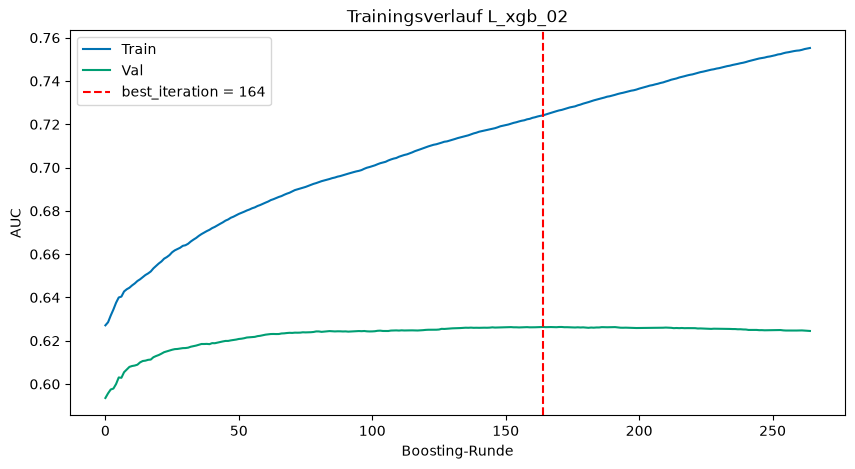

In [20]:
hist = xgb_02MK2.evals_result()

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(hist["validation_0"]["auc"], label="Train")
ax.plot(hist["validation_1"]["auc"], label="Val")
ax.axvline(xgb_02MK2.best_iteration,color="red", linestyle="--",
           label=f"best_iteration = {xgb_02MK2.best_iteration}")
ax.set_xlabel("Boosting-Runde")
ax.set_ylabel("AUC")
ax.set_title("Trainingsverlauf L_xgb_02")
ax.legend()

In [22]:
xgb_02MK3 = XGBClassifier(
    booster="gbtree",
    random_state=RANDOM_STATE,
    eval_metric="auc",
    tree_method="hist",
    enable_categorical=True,
    n_estimators=5000,
    learning_rate=0.03,
    early_stopping_rounds=100
)

In [23]:
name = "L_xgb_02MK3"

start = time.time()
xgb_02MK3.fit(
    x_train, y_train,
    eval_set=[(x_train, y_train), (x_val, y_val)],
    verbose=250
)
train_times[name] = time.time() - start

[0]	validation_0-auc:0.62712	validation_1-auc:0.59354
[250]	validation_0-auc:0.75164	validation_1-auc:0.62485
[264]	validation_0-auc:0.75526	validation_1-auc:0.62452


In [24]:
results.append(
    eval_modell(name, xgb_02MK3, x_train, y_train, x_val, y_val,
                train_times[name], best_iter=xgb_02MK3.best_iteration)
)
pd.DataFrame(results).set_index("model_idx")

,auc_train,auc_val,gini,delta_auc,best_iter,trainingszeit
model_idx,,,,,,
L_xgb_01,0.787872,0.617350,0.234700,0.170522,NaN,9.158222
L_xgb_02,0.720702,0.624260,0.248520,0.096442,91.0,32.358830
L_xgb_02MK2,0.724114,0.626369,0.252738,0.097745,164.0,50.719801
L_xgb_02MK3,0.724114,0.626369,0.252738,0.097745,164.0,55.023482


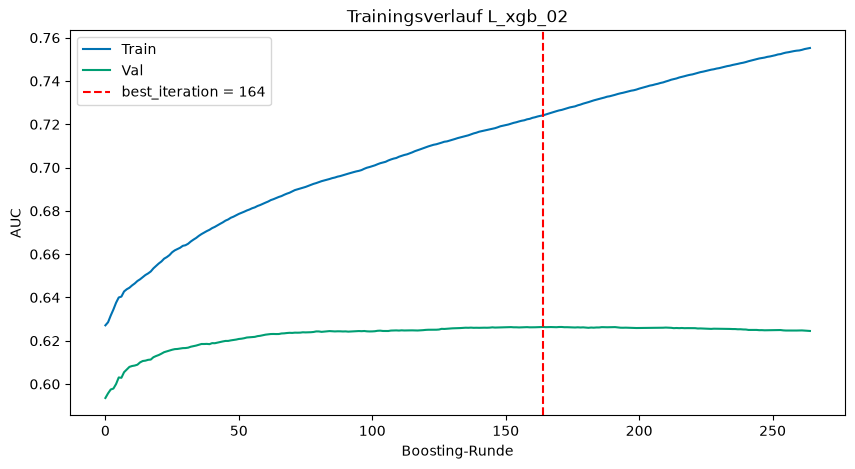

In [25]:
hist = xgb_02MK3.evals_result()

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(hist["validation_0"]["auc"], label="Train")
ax.plot(hist["validation_1"]["auc"], label="Val")
ax.axvline(xgb_02MK3.best_iteration,color="red", linestyle="--",
           label=f"best_iteration = {xgb_02MK3.best_iteration}")
ax.set_xlabel("Boosting-Runde")
ax.set_ylabel("AUC")
ax.set_title("Trainingsverlauf L_xgb_02")
ax.legend()

## L_xgb_03

In [27]:
xgb_03 = XGBClassifier(
    booster="gbtree",
    random_state=RANDOM_STATE,
    eval_metric="auc",
    tree_method="hist",
    enable_categorical=True,
    n_estimators=5000,
    learning_rate=0.03,
    early_stopping_rounds=100
)

In [28]:
name = "L_xgb_03"

start = time.time()
xgb_03.fit(
    x_train, y_train,
    eval_set=[(x_train, y_train), (x_val, y_val)],
    verbose=250
)
train_times[name] = time.time() - start

[0]	validation_0-auc:0.62712	validation_1-auc:0.59354
[250]	validation_0-auc:0.75164	validation_1-auc:0.62485
[264]	validation_0-auc:0.75526	validation_1-auc:0.62452


In [29]:
results.append(
    eval_modell(name, xgb_03, x_train, y_train, x_val, y_val,
                train_times[name], best_iter=xgb_03.best_iteration)
)
pd.DataFrame(results).set_index("model_idx")

,auc_train,auc_val,gini,delta_auc,best_iter,trainingszeit
model_idx,,,,,,
L_xgb_01,0.787872,0.617350,0.234700,0.170522,NaN,9.158222
L_xgb_02,0.720702,0.624260,0.248520,0.096442,91.0,32.358830
L_xgb_02MK2,0.724114,0.626369,0.252738,0.097745,164.0,50.719801
L_xgb_02MK3,0.724114,0.626369,0.252738,0.097745,164.0,55.023482
L_xgb_03,0.724114,0.626369,0.252738,0.097745,164.0,47.475546


In [30]:
setsizes = [0.1 ,0.25, 0.5, 0.75, 1.0]
sub_results = []
rng = np.random.default_rng(RANDOM_STATE)

for trainset in setsizes:
    n = int(len(x_train) * trainset)
    idx_sub = rng.permutation(len(x_train))[:n]
    x_sub, y_sub = x_train.iloc[idx_sub], y_train.iloc[idx_sub]

    model = clone(xgb_03)
    model.fit(
        x_sub, y_sub,
        eval_set=[(x_val, y_val)],
        verbose=False
        )

    sub_results.append({
        "train_size": n,
        "anteil": trainset,
        "best_iter": model.best_iteration,
        "auc_train": roc_auc_score(y_sub, model.predict_proba(x_sub)[:, 1]),
        "auc_val": roc_auc_score(y_val, model.predict_proba(x_val)[:, 1])
    })

df_sub_results = pd.DataFrame(sub_results)
df_sub_results

,train_size,anteil,best_iter,auc_train,auc_val
0,47616,0.10,63,0.828449,0.585714
1,119042,0.25,136,0.825066,0.607544
2,238084,0.50,125,0.755405,0.613575
3,357126,0.75,94,0.712071,0.620819
4,476168,1.00,184,0.731334,0.625482


Text(0.5, 1.0, 'XGBClassifier Learning Curve')

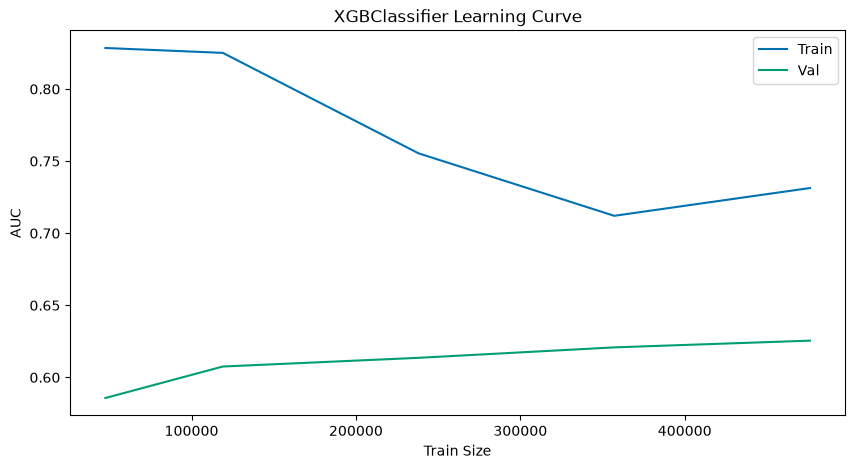

In [31]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(df_sub_results["train_size"], df_sub_results["auc_train"], label="Train")
ax.plot(df_sub_results["train_size"], df_sub_results["auc_val"], label="Val")
ax.set_xlabel("Train Size")
ax.set_ylabel("AUC")
ax.legend()
ax.set_title("XGBClassifier Learning Curve")

In [33]:
setsizes = [0.1 ,0.25, 0.5, 0.75, 1.0]
sub_results2 = []
rng = np.random.default_rng(RANDOM_STATE)

for trainset in setsizes:
    n = int(len(x_train) * trainset)
    idx_sub = rng.permutation(len(x_train))[:n]
    x_sub, y_sub = x_train[feat_cols_no_calc].iloc[idx_sub], y_train.iloc[idx_sub]

    model = clone(xgb_03)
    model.fit(
        x_sub[feat_cols_no_calc], y_sub,
        eval_set=[(x_val[feat_cols_no_calc], y_val)],
        verbose=False
    )

    sub_results2.append({
        "train_size": n,
        "anteil": trainset,
        "best_iter": model.best_iteration,
        "auc_train": roc_auc_score(y_sub, model.predict_proba(x_sub[feat_cols_no_calc])[:, 1]),
        "auc_val": roc_auc_score(y_val, model.predict_proba(x_val[feat_cols_no_calc])[:, 1])
    })

df_sub_results2 = pd.DataFrame(sub_results2)
df_sub_results2

,train_size,anteil,best_iter,auc_train,auc_val
0,47616,0.10,88,0.840132,0.590984
1,119042,0.25,70,0.758715,0.607201
2,238084,0.50,120,0.743226,0.615151
3,357126,0.75,98,0.709097,0.622000
4,476168,1.00,180,0.723087,0.627010


Text(0.5, 1.0, 'XGBClassifier Learning Curve without ps_calc features')

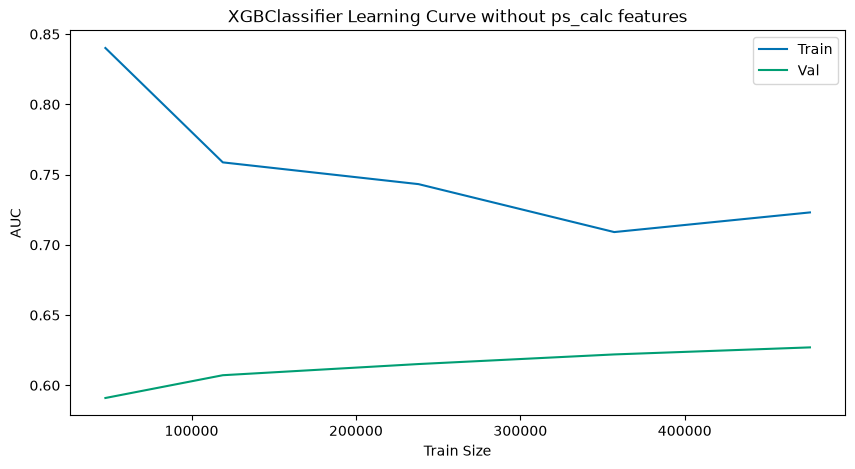

In [34]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(df_sub_results2["train_size"], df_sub_results2["auc_train"], label="Train")
ax.plot(df_sub_results2["train_size"], df_sub_results2["auc_val"], label="Val")
ax.set_xlabel("Train Size")
ax.set_ylabel("AUC")
ax.legend()
ax.set_title("XGBClassifier Learning Curve without ps_calc features")

## L_xgb_04

In [35]:
imbalance = (y_train == 0).sum() / (y_train == 1).sum()

In [36]:
xgb_04 = XGBClassifier(
    booster="gbtree",
    random_state=RANDOM_STATE,
    eval_metric="auc",
    tree_method="hist",
    enable_categorical=True,
    n_estimators=5000,
    learning_rate=0.03,
    early_stopping_rounds=100,
    scale_pos_weight=imbalance
)

In [37]:
name = "L_xgb_04"

start = time.time()
xgb_04.fit(
    x_train, y_train,
    eval_set=[(x_train, y_train), (x_val, y_val)],
    verbose=250
)
train_times[name] = time.time() - start

[0]	validation_0-auc:0.62846	validation_1-auc:0.59166
[250]	validation_0-auc:0.76299	validation_1-auc:0.61603
[261]	validation_0-auc:0.76606	validation_1-auc:0.61532


In [38]:
results.append(
    eval_modell(name, xgb_04, x_train, y_train, x_val, y_val,
                train_times[name], best_iter=xgb_04.best_iteration)
)
pd.DataFrame(results).set_index("model_idx")

,auc_train,auc_val,gini,delta_auc,best_iter,trainingszeit
model_idx,,,,,,
L_xgb_01,0.787872,0.617350,0.234700,0.170522,NaN,9.158222
L_xgb_02,0.720702,0.624260,0.248520,0.096442,91.0,32.358830
L_xgb_02MK2,0.724114,0.626369,0.252738,0.097745,164.0,50.719801
L_xgb_02MK3,0.724114,0.626369,0.252738,0.097745,164.0,55.023482
L_xgb_03,0.724114,0.626369,0.252738,0.097745,164.0,47.475546
L_xgb_04,0.732000,0.620886,0.241771,0.111114,161.0,43.174825


## L_xgb_05

In [39]:
xgb_05 = XGBClassifier(
    booster="gbtree",
    random_state=RANDOM_STATE,
    eval_metric="auc",
    tree_method="hist",
    enable_categorical=True,
    n_estimators=5000,
    learning_rate=0.03,
    early_stopping_rounds=100
)

In [40]:
name = "L_xgb_05"

start = time.time()
xgb_05.fit(
    x_train[feat_cols_no_calc], y_train,
    eval_set=[(x_train[feat_cols_no_calc], y_train), (x_val[feat_cols_no_calc], y_val)],
    verbose=250
)
train_times[name] = time.time() - start

[0]	validation_0-auc:0.62712	validation_1-auc:0.59356
[242]	validation_0-auc:0.73872	validation_1-auc:0.62428


In [41]:
results.append(
    eval_modell(name, xgb_05, x_train[feat_cols_no_calc], y_train, x_val[feat_cols_no_calc], y_val,
                train_times[name], best_iter=xgb_05.best_iteration)
)
pd.DataFrame(results).set_index("model_idx")

,auc_train,auc_val,gini,delta_auc,best_iter,trainingszeit
model_idx,,,,,,
L_xgb_01,0.787872,0.617350,0.234700,0.170522,NaN,9.158222
L_xgb_02,0.720702,0.624260,0.248520,0.096442,91.0,32.358830
L_xgb_02MK2,0.724114,0.626369,0.252738,0.097745,164.0,50.719801
L_xgb_02MK3,0.724114,0.626369,0.252738,0.097745,164.0,55.023482
L_xgb_03,0.724114,0.626369,0.252738,0.097745,164.0,47.475546
L_xgb_04,0.732000,0.620886,0.241771,0.111114,161.0,43.174825
L_xgb_05,0.711803,0.625833,0.251666,0.085970,142.0,66.868778


## Versuch für feature importance
Über get_booster

In [46]:
booster = xgb_03.get_booster()

importance = pd.DataFrame({
    "gain": pd.Series(booster.get_score(importance_type="gain")),
    "total_gain": pd.Series(booster.get_score(importance_type="total_gain")),
    "weight": pd.Series(booster.get_score(importance_type="weight")),
})

importance = importance.reindex(feat_cols).fillna(0) #nicht benutzte

importance["gruppe"] = np.select(
    [importance.index.str.startswith("ps_calc_"),
     importance.index.str.startswith("ps_car_"),
     importance.index.str.startswith("ps_ind_"),
     importance.index.str.startswith("ps_reg_")],
    ["calc", "car", "ind", "reg"], default="andere"
)
importance["rang"] = importance["gain"].rank(ascending=False).astype(int)

importance.sort_values("gain", ascending=False).head(15)

,gain,total_gain,weight,gruppe,rang
ps_ind_06_bin,54.741833,3941.411865,72.0,ind,1
ps_car_13,38.660313,17551.781250,454.0,car,2
ps_ind_17_bin,38.281357,7388.301758,193.0,ind,3
ps_ind_05_cat,28.147438,15481.090820,550.0,ind,4
ps_ind_16_bin,26.424776,1902.583862,72.0,ind,5
ps_ind_07_bin,24.886915,2190.048584,88.0,ind,6
ps_car_03_cat,20.496267,1926.649048,94.0,car,7
ps_car_11_cat,18.248442,81023.078125,4440.0,car,8
ps_car_07_cat,17.711111,2514.977783,142.0,car,9
ps_ind_09_bin,15.638014,1110.298950,71.0,ind,10


In [49]:
importance.groupby("gruppe").agg(
    n_features=("gain", "size"),
    n_ungenutzt=("total_gain", lambda a: (a == 0).sum()),
    gain_anteil=("total_gain", lambda a: a.sum() / importance["total_gain"].sum()),
    median_rang=("rang", "median"),
).sort_values("gain_anteil", ascending=False)

,n_features,n_ungenutzt,gain_anteil,median_rang
gruppe,,,,
car,16,0,0.558011,22.5
ind,18,2,0.235068,15.5
calc,20,0,0.107821,40.5
reg,3,0,0.099100,12.0


Text(0.5, 1.0, 'feature importance über total_gain, L_xgb_03')

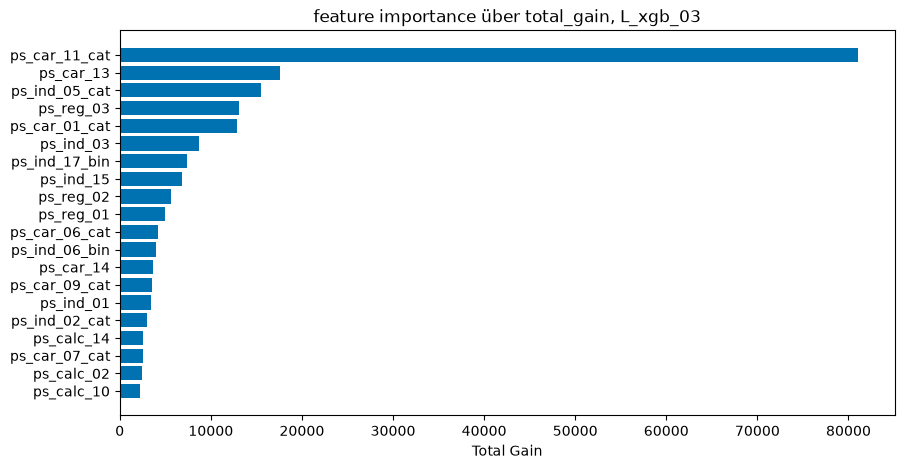

In [50]:
top = importance.sort_values("total_gain").tail(20)

fig, ax = plt.subplots(figsize=(10, 5))

ax.barh(top.index, top["total_gain"])
ax.set_xlabel("Total Gain")
ax.set_title("feature importance über total_gain, L_xgb_03")

## L_xgb_06

In [51]:
# nur target ecoding
targ_enc = TargetEncoder(cv=5, random_state=RANDOM_STATE)

x_train_06 = x_train.copy()
x_val_06 = x_val.copy()

x_train_06["ps_car_11_cat"] = targ_enc.fit_transform(
    x_train[high_kard_cols], y_train
).astype("float32")
x_val_06["ps_car_11_cat"] = targ_enc.transform(
    x_val[high_kard_cols]
).astype("float32")

x_train_06["ps_car_11_cat"].describe()

c:\Users\Linus Lauschke\anaconda3\envs\ADA\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


count    476168.000000
mean          0.036446
std           0.009676
min           0.016329
25%           0.028362
50%           0.034718
75%           0.044178
max           0.078113
Name: ps_car_11_cat, dtype: float64

In [52]:
xgb_06 = XGBClassifier(
    booster="gbtree",
    random_state=RANDOM_STATE,
    eval_metric="auc",
    tree_method="hist",
    enable_categorical=True,
    n_estimators=5000,
    learning_rate=0.03,
    early_stopping_rounds=100
)

In [53]:
name = "L_xgb_06"

start = time.time()
xgb_06.fit(
    x_train_06, y_train,
    eval_set=[(x_train_06, y_train), (x_val_06, y_val)],
    verbose=250
)
train_times[name] = time.time() - start

[0]	validation_0-auc:0.62008	validation_1-auc:0.60168
[250]	validation_0-auc:0.71734	validation_1-auc:0.63396
[307]	validation_0-auc:0.72740	validation_1-auc:0.63343


In [54]:
results.append(
    eval_modell(name, xgb_06, x_train_06, y_train, x_val_06, y_val,
                train_times[name], best_iter=xgb_06.best_iteration)
)
pd.DataFrame(results).set_index("model_idx")

,auc_train,auc_val,gini,delta_auc,best_iter,trainingszeit
model_idx,,,,,,
L_xgb_01,0.787872,0.617350,0.234700,0.170522,NaN,9.158222
L_xgb_02,0.720702,0.624260,0.248520,0.096442,91.0,32.358830
L_xgb_02MK2,0.724114,0.626369,0.252738,0.097745,164.0,50.719801
L_xgb_02MK3,0.724114,0.626369,0.252738,0.097745,164.0,55.023482
L_xgb_03,0.724114,0.626369,0.252738,0.097745,164.0,47.475546
L_xgb_04,0.732000,0.620886,0.241771,0.111114,161.0,43.174825
L_xgb_05,0.711803,0.625833,0.251666,0.085970,142.0,66.868778
L_xgb_06,0.709208,0.634325,0.268650,0.074883,207.0,45.283479


## L_xgb_07

In [56]:
# nur target ecoding
targ_enc_no_calc = TargetEncoder(cv=5, random_state=RANDOM_STATE)

x_train_06_no_calc = x_train[feat_cols_no_calc].copy()
x_val_06_no_calc = x_val[feat_cols_no_calc].copy()

x_train_06_no_calc["ps_car_11_cat"] = targ_enc_no_calc.fit_transform(
    x_train[high_kard_cols], y_train
).astype("float32")
x_val_06_no_calc["ps_car_11_cat"] = targ_enc_no_calc.transform(
    x_val[high_kard_cols]
).astype("float32")

x_train_06_no_calc["ps_car_11_cat"].describe()

c:\Users\Linus Lauschke\anaconda3\envs\ADA\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


count    476168.000000
mean          0.036446
std           0.009676
min           0.016329
25%           0.028362
50%           0.034718
75%           0.044178
max           0.078113
Name: ps_car_11_cat, dtype: float64

In [57]:
xgb_07 = XGBClassifier(
    booster="gbtree",
    random_state=RANDOM_STATE,
    eval_metric="auc",
    tree_method="hist",
    enable_categorical=True,
    n_estimators=5000,
    learning_rate=0.03,
    early_stopping_rounds=100
)

In [58]:
name = "L_xgb_07"

start = time.time()
xgb_07.fit(
    x_train_06_no_calc, y_train,
    eval_set=[(x_train_06_no_calc, y_train), (x_val_06_no_calc, y_val)],
    verbose=250
)
train_times[name] = time.time() - start

[0]	validation_0-auc:0.62021	validation_1-auc:0.60116
[250]	validation_0-auc:0.70883	validation_1-auc:0.63519
[397]	validation_0-auc:0.72770	validation_1-auc:0.63500


In [59]:
results.append(
    eval_modell(name, xgb_07, x_train_06_no_calc, y_train, x_val_06_no_calc, y_val,
                train_times[name], best_iter=xgb_07.best_iteration)
)
pd.DataFrame(results).set_index("model_idx")

,auc_train,auc_val,gini,delta_auc,best_iter,trainingszeit
model_idx,,,,,,
L_xgb_01,0.787872,0.617350,0.234700,0.170522,NaN,9.158222
L_xgb_02,0.720702,0.624260,0.248520,0.096442,91.0,32.358830
L_xgb_02MK2,0.724114,0.626369,0.252738,0.097745,164.0,50.719801
L_xgb_02MK3,0.724114,0.626369,0.252738,0.097745,164.0,55.023482
L_xgb_03,0.724114,0.626369,0.252738,0.097745,164.0,47.475546
L_xgb_04,0.732000,0.620886,0.241771,0.111114,161.0,43.174825
L_xgb_05,0.711803,0.625833,0.251666,0.085970,142.0,66.868778
L_xgb_06,0.709208,0.634325,0.268650,0.074883,207.0,45.283479
L_xgb_07,0.716012,0.635750,0.271500,0.080262,297.0,50.296406


## Notizen
Punkte aus der EDA, die ich hier behandeln möchte:
|Gedanke|Umsetzung|
|---|---|
|||


Punkte aus der Aufgabenstellung, die ich hier behandeln möchte:
- Learning Curve vor Modelltraining

Modelle im Notebook:
|Modell Index|Spezifikation
|---|---|
|L_xgb_01|Simple aus 06 als Bezugspunkt|
|L_xgb_02|nativ verarbeiten mit mehr kapazität|
|L_xgb_03|enable categorical unterschied? + calc drop learning curves|
|L_xgb_04|klassenimbalance über scale_pos_weights|
|L_xgb_05|real no calc weil vorin fehler gemacht|
|L_xgb_06|beste kombi mit target encoding|
|L_xgb_07|06 ohne calc|


- https://xgboost.readthedocs.io/en/stable/
- https://mljourney.com/xgboost-feature-importance-comprehensive-guide/
- https://xgboost.readthedocs.io/en/latest/r_docs/R-package/docs/reference/xgb.importance.html
- https://stackoverflow.com/questions/37627923/how-to-get-feature-importance-in-xgboost
